17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 314ms/step - accuracy: 0.7660 - loss: 0.4700 - val_accuracy: 0.8476 - val_loss: 0.3490
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 313ms/step - accuracy: 0.8881 - loss: 0.2828 - val_accuracy: 0.8438 - val_loss: 0.5781
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 325ms/step - accuracy: 0.9233 - loss: 0.2060 - val_accuracy: 0.8752 - val_loss: 0.3350
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 324ms/step - accuracy: 0.9259 - loss: 0.1861 - val_accuracy: 0.8398 - val_loss: 0.4272
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 103s 330ms/step - accuracy: 0.8790 - loss: 0.2794 - val_accuracy: 0.7686 - val_loss: 0.4959
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.7785 - loss: 0.4916
Test Accuracy: 0.7784799933433533


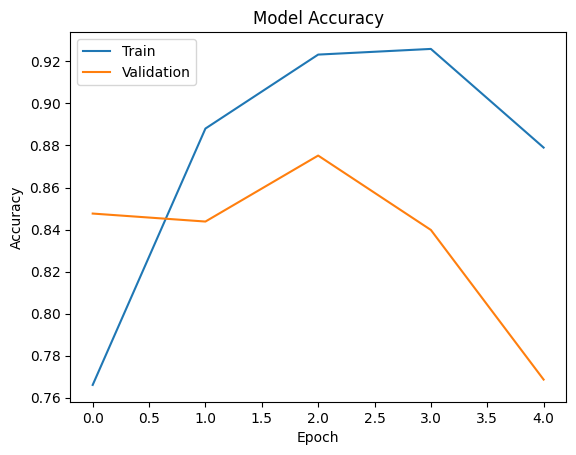

In [ ]:
# ============================================
# LSTM for Text Classification (IMDB Dataset) part 1
# ============================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1️⃣ Load Dataset
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# 2️⃣ Padding
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# 3️⃣ Build LSTM Model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

# 4️⃣ Train Model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# 5️⃣ Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# 6️⃣ Plot Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
# ============================================
# LSTM Sequence-to-Sequence Model
# ============================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense

# 1️⃣ Create Dummy Data
num_samples = 10000
max_len = 5
vocab_size = 50

X = np.random.randint(1, vocab_size, size=(num_samples, max_len))
y = np.flip(X, axis=1)

# One-hot encoding
X = tf.keras.utils.to_categorical(X, num_classes=vocab_size)
y = tf.keras.utils.to_categorical(y, num_classes=vocab_size)

# 2️⃣ Define Model Parameters
latent_dim = 128

# Encoder
encoder_inputs = Input(shape=(max_len, vocab_size))
encoder_lstm = LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(max_len, vocab_size))
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs,
                                     initial_state=encoder_states)

decoder_dense = Dense(vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Seq2Seq Model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 3️⃣ Train Model
model.fit([X, X], y,
          batch_size=64,
          epochs=5,
          validation_split=0.2)

# 4️⃣ Test Model
test_input = np.random.randint(1, vocab_size, size=(1, max_len))
test_input_oh = tf.keras.utils.to_categorical(test_input,
                                              num_classes=vocab_size)

prediction = model.predict([test_input_oh, test_input_oh])
predicted_sequence = np.argmax(prediction, axis=-1)

print("Input Sequence:", test_input)
print("Predicted Output:", predicted_sequence)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 5, 50)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 5, 50)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 128),     │     91,648 │ input_layer_1[0]… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 5, 128),  │     91,648 │ input_layer_2[0]… │
│                     │ (None, 128),      │            │ lstm_1[0][1],     │
│                     │ (None, 128)]      │            │ lstm_1[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 5, 50)     │      6,450 │ lstm_2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 189,746 (741.20 KB)

 Trainable params: 189,746 (741.20 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.1865 - loss: 3.1407 - val_accuracy: 0.2271 - val_loss: 2.3558
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2446 - loss: 2.1759 - val_accuracy: 0.2596 - val_loss: 2.0624
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.2926 - loss: 1.9163 - val_accuracy: 0.3182 - val_loss: 1.8474
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.3709 - loss: 1.6785 - val_accuracy: 0.3984 - val_loss: 1.6287
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4654 - loss: 1.4334 - val_accuracy: 0.4843 - val_loss: 1.4122
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Input Sequence: [[43  4 13 11 41]]
Predicted Output: [[41 43 43 43  4]]
